In [ ]:
from google.colab import files
import zipfile
import os

# Загружаем ZIP-файл
print("Выберите скачанный ZIP-файл с датасетом")
uploaded = files.upload()

# Получаем имя файла
zip_filename = list(uploaded.keys())[0]
print(f"Загружен файл: {zip_filename}")

# Разархивируем
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('hard-hat-dataset')

print("Датасет разархивирован!")

# Смотрим структуру
print("\nСтруктура датасета:")
!ls -la hard-hat-dataset/

Выберите скачанный ZIP-файл с датасетом


Saving Hard Hat Workers.v10-raw_allclasses.yolov8.zip to Hard Hat Workers.v10-raw_allclasses.yolov8.zip
Загружен файл: Hard Hat Workers.v10-raw_allclasses.yolov8.zip
Датасет разархивирован!

Структура датасета:
total 32
drwxr-xr-x 5 root root 4096 Apr 11 10:01 .
drwxr-xr-x 1 root root 4096 Apr 11 10:00 ..
-rw-r--r-- 1 root root  291 Apr 11 10:00 data.yaml
-rw-r--r-- 1 root root 4037 Apr 11 10:00 README.dataset.txt
-rw-r--r-- 1 root root  960 Apr 11 10:00 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Apr 11 10:01 test
drwxr-xr-x 4 root root 4096 Apr 11 10:01 train
drwxr-xr-x 4 root root 4096 Apr 11 10:01 valid


Найдена папка датасета: hard-hat-dataset

КОЛИЧЕСТВО ИЗОБРАЖЕНИЙ
TRAIN: 4916
VALID: 1413
TEST: 706

ВСЕГО: 7035

РАСПРЕДЕЛЕНИЕ ОБЪЕКТОВ ПО КЛАССАМ
helmet: 19747
person: 6677
head: 615


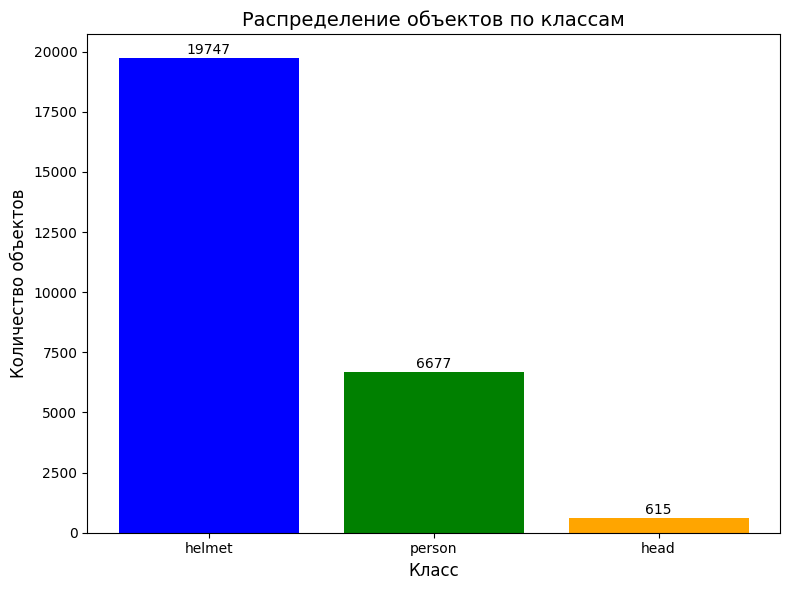


Диаграмма сохранена как 'class_distribution.png'

Структура папки датасета:
hard-hat-dataset
hard-hat-dataset/valid
hard-hat-dataset/valid/images
hard-hat-dataset/valid/labels
hard-hat-dataset/train
hard-hat-dataset/train/images
hard-hat-dataset/train/labels
hard-hat-dataset/test
hard-hat-dataset/test/images
hard-hat-dataset/test/labels


In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt

# Путь к датасету (Roboflow создает папку с названием проекта)
dataset_path = "hard-hat-dataset/hard-hat-workers-10"  # или похожее имя

# Если папка не найдена, ищем
if not os.path.exists(dataset_path):
    for root, dirs, files in os.walk("hard-hat-dataset"):
        if 'train' in dirs and 'valid' in dirs:
            dataset_path = root
            print(f"Найдена папка датасета: {dataset_path}")
            break

# Подсчет изображений
splits = ['train', 'valid', 'test']
image_counts = {}

for split in splits:
    images_dir = os.path.join(dataset_path, split, 'images')
    if os.path.exists(images_dir):
        count = len([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])
        image_counts[split] = count
    else:
        image_counts[split] = 0

print("\n" + "="*40)
print("КОЛИЧЕСТВО ИЗОБРАЖЕНИЙ")
print("="*40)
for split, count in image_counts.items():
    print(f"{split.upper()}: {count}")
print(f"\nВСЕГО: {sum(image_counts.values())}")

# Подсчет объектов по классам
class_counts = Counter()
class_names = {0: "person", 1: "helmet", 2: "head"}

for split in splits:
    labels_dir = os.path.join(dataset_path, split, 'labels')
    if not os.path.exists(labels_dir):
        continue
    for label_file in os.listdir(labels_dir):
        if not label_file.endswith('.txt'):
            continue
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1

print("\n" + "="*40)
print("РАСПРЕДЕЛЕНИЕ ОБЪЕКТОВ ПО КЛАССАМ")
print("="*40)
for class_id, count in class_counts.items():
    print(f"{class_names.get(class_id, class_id)}: {count}")

# Визуализация
if class_counts:
    plt.figure(figsize=(8, 6))
    classes = [class_names.get(cid, str(cid)) for cid in class_counts.keys()]
    counts = list(class_counts.values())
    colors = ['blue', 'green', 'orange'][:len(classes)]

    bars = plt.bar(classes, counts, color=colors)
    plt.title('Распределение объектов по классам', fontsize=14)
    plt.xlabel('Класс', fontsize=12)
    plt.ylabel('Количество объектов', fontsize=12)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 50,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=300)
    plt.show()
    print("\nДиаграмма сохранена как 'class_distribution.png'")
else:
    print("Не удалось найти файлы разметки. Проверьте структуру папок.")

# Покажем структуру для отладки
print("\nСтруктура папки датасета:")
!find {dataset_path} -type d | head -20

In [ ]:
!apt-get install tree -qq
!tree hard-hat-dataset -d

hard-hat-dataset
├── test
│   ├── images
│   └── labels
├── train
│   ├── images
│   └── labels
└── valid
    ├── images
    └── labels

9 directories
